In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pystac_client
import fsspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer

# Introduction

This notebook serves as a concise guide to working with **Zarr**, using
the Sentinel‑5P archive.  We'll cover:

- discovering a Zarr store using STAC
- opening a Zarr store with `xarray`
- accessing and inspecting product groups
- efficient time slicing and variable extraction
- handling missing data, spatial aggregation, and plotting
- optional map visualisations

Practical snippets will help you migrate existing NetCDF workflows to
Zarr.


## Introduction to the Zarr data format

Zarr is an open-source format for the storage of chunked, compressed,
and N‑dimensional arrays.  It stores metadata in JSON and array data
in binary chunks which can live on local disk, network file systems, or
object stores.  Because the chunks are independent, Zarr supports
parallel reads/writes and incremental updates.

## Discovering the Zarr store through STAC

We begin by connecting to the STAC API provided by EODC. 
This interface allows us to explore the available STAC collections and identify the corresponding endpoints for accessing the underlying datasets, including Zarr stores.

In [ ]:
eodc_catalog = pystac_client.Client.open("https://stac.eodc.eu/api/v1")


value = "tropomi" # free text search term

results = eodc_catalog.collection_search(
    q = value
)

for coll in results.collections():
    print(f"ID: {coll.id}, Title: {coll.title}")

collection_id = "SENTINEL5P_DAILY_AUT"                    # ID identified in the previous step.
collection = eodc_catalog.get_collection(collection_id)

# Zarr store URL (this is NOT a file, but a "virtual filesystem")
store_url = collection.get_single_link("store").href

ID: SENTINEL5P_DAILY_AUT, Title: Sentinel-5P Daily Aggregated Atmospheric Data for Austria


We can now explore the different data products available within the collection and inspect their corresponding Zarr-based representations. In addition, we can retrieve the specific endpoints that provide access to these datasets.

In [3]:
collection.assets

{'CO': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/CO>,
 'O3': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/O3>,
 'CH4': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/CH4>,
 'NO2': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/NO2>,
 'SO2': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/SO2>,
 'HCHO': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/HCHO>,
 'CLOUD': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/CLOUD>,
 'AER_AI': <Asset href=http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/AER_AI>,
 'thumbnail': <Asset href=https://objects.eodc.eu/88346baf22914e828ad2c1763e5e01ff:s5p-thumbnail/s5p_overview.png>}

The `collection` object holds all the information about the Sentinel-5P Zarr Data Cube. We can look up the link to access the data manually (e.g., inspect the cell output by executing `collection`), or we can identify it automatically, knowing that the link relation that points to the Zarr store is always named `store`, as we have done above.

Similarly, we can directly obtain the access location for a specific product type using the collection's assets objects listed above:

In [4]:
product_type = "CO"
co_path = collection.assets[product_type].href

co_path

'http://data.eodc.eu/collections/SENTINEL5P/s5p-daily-aut-10km.zarr/CO'

## Opening a Zarr store using xarray


### Accessing product groups within a Zarr archive

Zarr allows you to organise multiple products under one store; we
opened the `CO` group above, but you can list groups via `zarr.open`.


In [7]:
import fsspec
import zarr

mapper = fsspec.get_mapper(store_url)           # or directly: mapper = zarr.storage.FsspecStore.from_url(store_url)
root = zarr.open_group(mapper, mode="r")

print("Subgroups:", list(root.group_keys()))

# A Zarr store can contain multiple groups (like folders).
# Each group corresponds to a product (e.g., "CO", "NO2", etc.)

Subgroups: ['AER_AI', 'CH4', 'CLOUD', 'CO', 'HCHO', 'NO2', 'O3', 'SO2']


We'll open the Sentinel‑5P archive.

In [8]:
ds = xr.open_zarr(store_url, group="CO", consolidated=True)

Note: Opening a Zarr store does NOT load data into memory.
Data is only loaded when values are accessed (e.g. `.values`, `.plot()`, or aggregations like `.mean()`).

### Inspecting dataset structure

We can look at dimensions, variables and chunking information.


In [9]:
ds

<xarray.Dataset> Size: 645MB
Dimensions:                        (time: 2440, qa_threshold: 3, y: 91, x: 121)
Coordinates:
  * time                           (time) datetime64[ns] 20kB 2018-07-05 ... ...
  * qa_threshold                   (qa_threshold) float64 24B 0.0 0.5 0.75
  * y                              (y) float64 728B 2.029e+06 ... 1.129e+06
  * x                              (x) float64 968B 4.437e+06 ... 5.637e+06
    spatial_ref                    int64 8B ...
Data variables:
    carbonmonoxide_total_column    (time, qa_threshold, y, x) float32 322MB dask.array<chunksize=(1, 1, 91, 121), meta=np.ndarray>
    carbonmonoxide_total_column_n  (time, qa_threshold, y, x) int32 322MB dask.array<chunksize=(1, 1, 91, 121), meta=np.ndarray>

In [10]:
ds.dims

FrozenMappingWarningOnValuesAccess({'time': 2440, 'qa_threshold': 3, 'y': 91, 'x': 121})

In [11]:
ds.data_vars

Data variables:
    carbonmonoxide_total_column    (time, qa_threshold, y, x) float32 322MB dask.array<chunksize=(1, 1, 91, 121), meta=np.ndarray>
    carbonmonoxide_total_column_n  (time, qa_threshold, y, x) int32 322MB dask.array<chunksize=(1, 1, 91, 121), meta=np.ndarray>

First we'll select a variable:

In [12]:
carbon = ds.carbonmonoxide_total_column
carbon.dims

('time', 'qa_threshold', 'y', 'x')

### Handle extra dimensions (qa_threshold)

Then we'll handle the qa_value. We can look at the different thresholds and pick one:

In [13]:
carbon.qa_threshold

<xarray.DataArray 'qa_threshold' (qa_threshold: 3)> Size: 24B
array([0.  , 0.5 , 0.75])
Coordinates:
  * qa_threshold  (qa_threshold) float64 24B 0.0 0.5 0.75
    spatial_ref   int64 8B ...

In [14]:
carbon = carbon.sel(qa_threshold=0.5)

## Time slicing

Now, that we've selected a variable, chose a qa_threshold, we can slice a time of interest.

In [15]:
START_DATE = "2024-01-01"
END_DATE = "2024-12-31"

carbon = carbon.sel(time=slice(START_DATE, END_DATE))

## Handling Missing and Fill Values (Sanity Check)

By default, **xarray** automatically decodes CF-compliant metadata, including `_FillValue`, and converts declared missing values to `NaN`.  

Even so, performing a brief sanity check is good practice to confirm that the dataset has been decoded correctly and is ready for analysis.

We can retrieve the "nodata" and "scale" value from STAC:

In [16]:
asset = collection.to_dict()["assets"]["CO"]["raster:bands"][0]
nodata = asset["nodata"]
scale = asset["scale"]
print("nodata:", nodata)
print("scale:", scale)

# Optional masking (usually not needed)
if nodata is not None:
    carbon = carbon.where(carbon != nodata) # Usually unnecessary — xarray already handled this

nodata: 9.969209968386869e+36
scale: 1.0


In [18]:
# How many NaNs are there?
n_missing = carbon.isnull().compute().sum().item()
n_valid = carbon.notnull().compute().sum().item()
print(f"Number of missing values (NaN): {n_missing}")
print(f"Number of valid values: {n_valid}")

# Optionally, check min/max to see if fill values were decoded
print("Min value:", float(carbon.min()))
print("Max value:", float(carbon.max()))

Number of missing values (NaN): 2023127
Number of valid values: 1951844
Min value: 0.010895281098783016
Max value: 0.061888013035058975


## Performing spatial aggregation

In [19]:
spatial_mean = carbon.mean(dim=("y","x"))
spatial_mean

<xarray.DataArray 'carbonmonoxide_total_column' (time: 361)> Size: 1kB
dask.array<mean_agg-aggregate, shape=(361,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time          (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
    qa_threshold  float64 8B 0.5
    spatial_ref   int64 8B ...
Attributes:
    units:                                                 mol m-2
    long_name:                                             Vertically integra...
    multiplication_factor_to_convert_to_molecules_percm2:  6.022140853952394e+19
    cell_methods:                                          time: mean
    comment:                                               Daily mean derived...
    grid_mapping:                                          spatial_ref

## Creating temporal plots of aggregated data

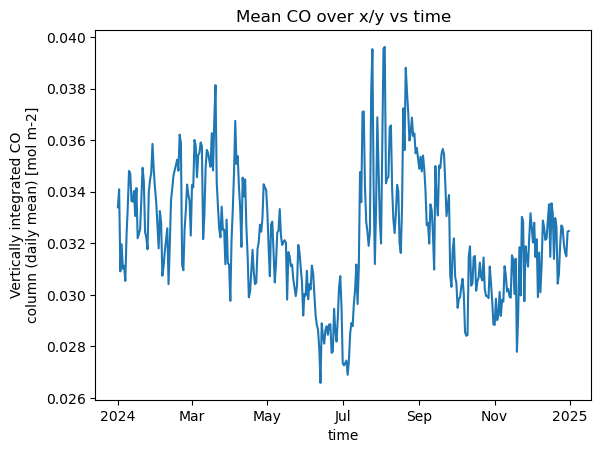

In [20]:
fig, ax = plt.subplots()
spatial_mean.plot(ax=ax)
ax.set_title("Mean CO over x/y vs time")
plt.show()


## Optional spatial visualization on a map

We can retrieve the EPSG directly from ZARR.

In [22]:
from pyproj import CRS

crs = CRS.from_wkt(ds["spatial_ref"].attrs["crs_wkt"])
crs = f"EPSG:{crs.to_epsg()}"
crs

'EPSG:27704'

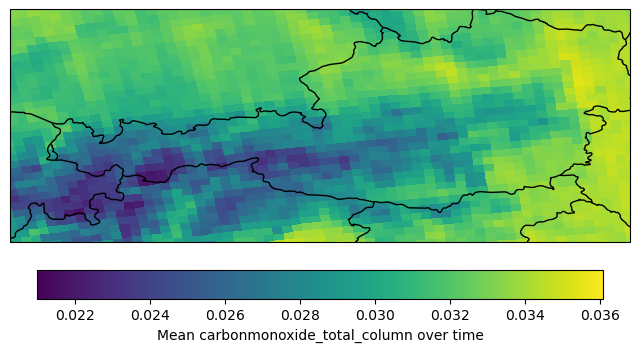

In [24]:
# Variable name to plot
var_name = "carbonmonoxide_total_column"

# Create a transformer to convert from the dataset CRS (EPSG:27704) to WGS84 (EPSG:4326)
# This is needed because Cartopy expects latitude/longitude coordinates
transformer = Transformer.from_crs(f"{crs}", "EPSG:4326", always_xy=True)

# Create 2D meshgrid of the dataset coordinates
# X corresponds to the 'x' dimension and Y to the 'y' dimension
X, Y = np.meshgrid(carbon["x"].values, carbon["y"].values)

# Transform coordinates from projected CRS to latitude and longitude
lons, lats = transformer.transform(X, Y)

# Compute the mean over time to get a 2D array (spatial average)
mean_image = carbon.mean(dim="time").values  # 2D array: y * x

# Create a matplotlib figure with a Cartopy PlateCarree projection
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.PlateCarree()})

# Add map features: country borders, coastlines, and land background
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Set the map extent to the area of interest (here: roughly Austria)
ax.set_extent([9, 17, 46, 49], crs=ccrs.PlateCarree())

# Plot the 2D data as a colored mesh on the map
im = ax.pcolormesh(
    lons, lats, mean_image,
    cmap='viridis',             # color map
    vmin=mean_image.min(),      # minimum value for color scale
    vmax=mean_image.max(),      # maximum value for color scale
    transform=ccrs.PlateCarree() # specify that data is in lat/lon
)

# Add a horizontal colorbar below the map to indicate values
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.046, pad=0.046)
cbar.set_label(f"Mean {var_name} over time")

# Display the figure
plt.show()